# OSM Land Use Features - Viladecans

Downloads OSM land use polygons for Viladecans (landuse + leisure parks), computes the percentage
of green, commercial, and industrial area within a 50 m buffer of each street segment,
and exports `data/osm_landuse_features.csv`.
Roads loaded from `../layers/VIL_noise_streets.gpkg`.

In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import osmnx as ox
import os

## Load roads

In [2]:
osm_roads = gpd.read_file("../layers/VIL_noise_streets.gpkg")
print(osm_roads.crs)
print(osm_roads.shape)
print(osm_roads.columns.tolist())
print("Number of street segments:", len(osm_roads))

EPSG:25831
(1613, 12)
['segment_id', 'highway', 'name', 'length', 'db_day', 'db_evening', 'db_night', 'noise_day', 'noise_evening', 'noise_night', 'distance', 'geometry']
Number of street segments: 1613


C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\core.py:34: RuntimeWarning: Could not detect GDAL data files. Set GDAL_DATA environment variable to the correct path.
  _init_gdal_data()


## Load / Download OSM Land Use

In [3]:
landuse_cache = 'data/vil_osm_landuse.gpkg'
os.makedirs('data', exist_ok=True)

if os.path.exists(landuse_cache):
    osm_landuse = gpd.read_file(landuse_cache)
    print(f'Loaded from cache: {len(osm_landuse)} polygons')
else:
    print('Downloading landuse from OSM...')

    lu = ox.features_from_place('Viladecans, Spain', tags={'landuse': True})
    lu = lu[lu.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()
    lu['fclass'] = lu['landuse'].apply(lambda x: x[0] if isinstance(x, list) else str(x))

    parks = ox.features_from_place('Viladecans, Spain',
                                    tags={'leisure': ['park', 'garden', 'nature_reserve', 'recreation_ground']})
    parks = parks[parks.geometry.type.isin(['Polygon', 'MultiPolygon'])].copy()
    parks['fclass'] = parks['leisure'].apply(
        lambda x: 'recreation_ground' if str(x) == 'recreation_ground' else 'park')

    combined = gpd.GeoDataFrame(
        pd.concat([lu[['fclass', 'geometry']], parks[['fclass', 'geometry']]], ignore_index=True),
        crs='EPSG:4326'
    ).reset_index(drop=True)
    combined = combined[combined.geometry.notna()]
    combined.to_file(landuse_cache, driver='GPKG')
    osm_landuse = combined
    print(f'Downloaded and cached: {len(osm_landuse)} polygons')

if osm_landuse.crs != osm_roads.crs:
    osm_landuse = osm_landuse.to_crs(osm_roads.crs)

print('CRS:', osm_landuse.crs)
print('Shape:', osm_landuse.shape)
display(osm_landuse.head(2))

Downloaded and cached: 854 polygons
CRS: EPSG:25831
Shape: (854, 2)


C:\Users\giofo\miniconda3\envs\data-encoding\Lib\site-packages\pyogrio\raw.py:733: RuntimeWarning: Cannot find tms_NZTM2000.json (GDAL_DATA is not defined)
  ogr_write(


,fclass,geometry
0,residential,"POLYGON ((418340.29 4568845.316, 418345.872 45..."
1,forest,"POLYGON ((420122.615 4569561.771, 420125.164 4..."


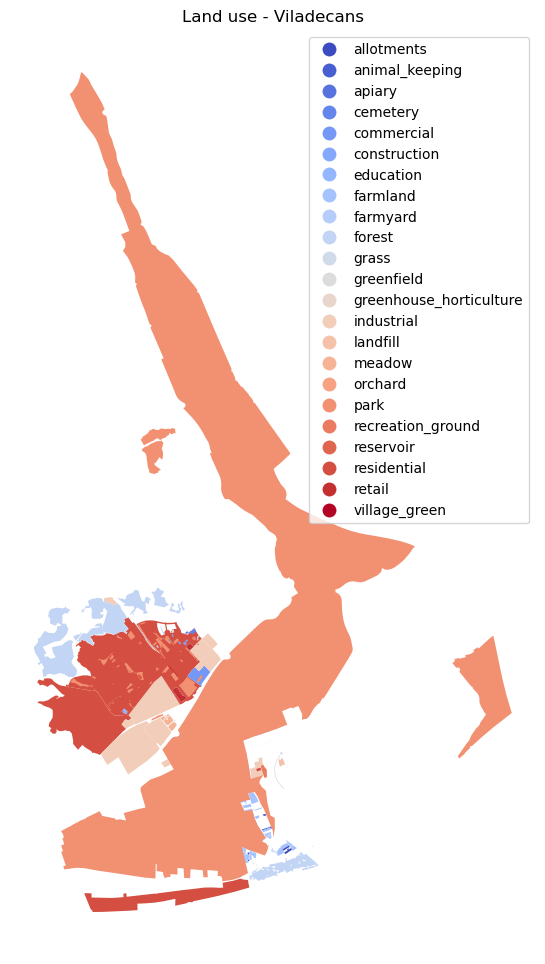

In [4]:
ax = osm_landuse.plot(cmap='coolwarm', column='fclass', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_title('Land use - Viladecans')
ax.set_axis_off()

## Categorize OSM Land Use
Map OSM `fclass` values to ML buckets: green, commercial, industrial, residential, other.

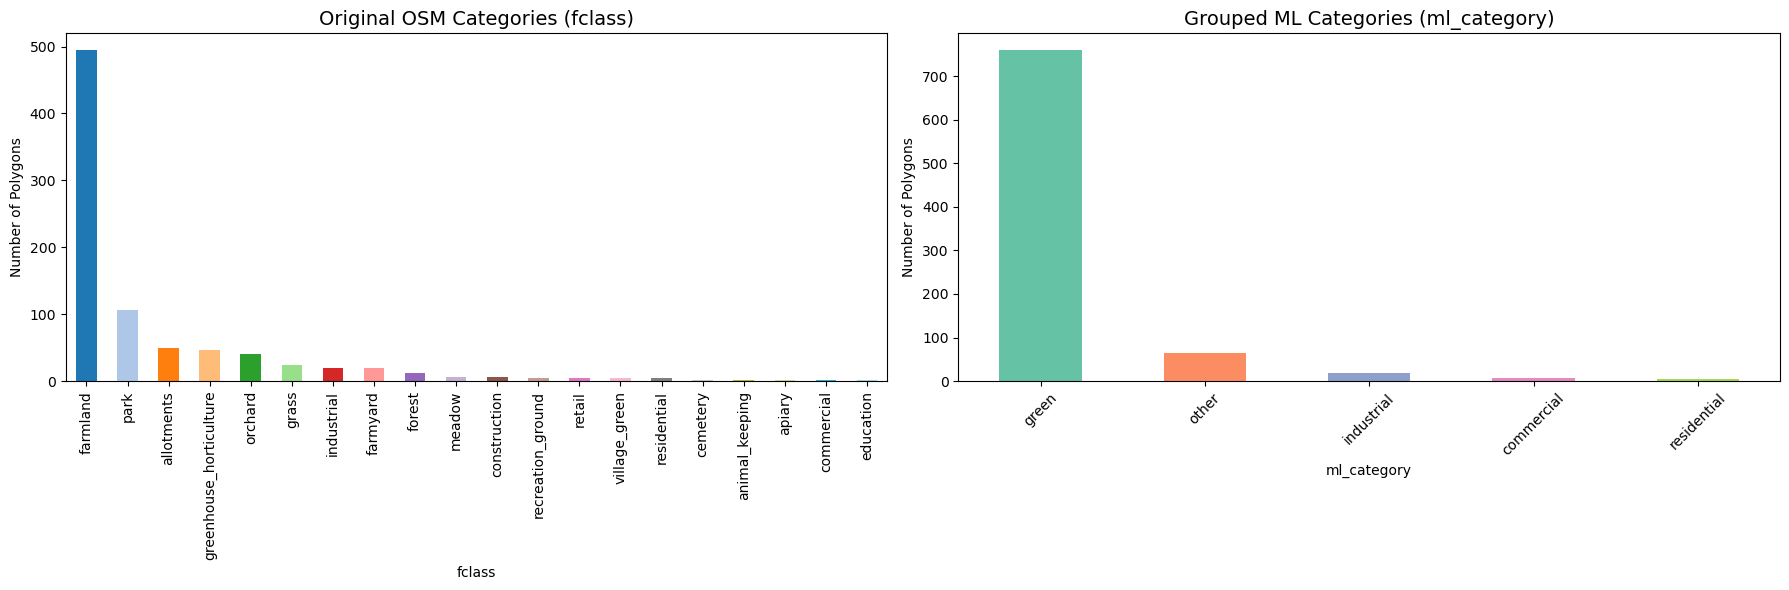

In [5]:
osm_to_ml_buckets = {
    'residential': 'residential',
    'commercial': 'commercial',
    'retail': 'commercial',
    'industrial': 'industrial',
    'quarry': 'industrial',
    'allotments': 'green',
    'cemetery': 'green',
    'farmland': 'green',
    'farmyard': 'green',
    'forest': 'green',
    'grass': 'green',
    'heath': 'green',
    'meadow': 'green',
    'orchard': 'green',
    'park': 'green',
    'recreation_ground': 'green',
    'scrub': 'green',
    'vineyard': 'green',
    'military': 'other'
}

osm_landuse['ml_category'] = osm_landuse['fclass'].map(osm_to_ml_buckets).fillna('other')

fclass_counts = osm_landuse['fclass'].value_counts()
ml_counts = osm_landuse['ml_category'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fclass_counts.head(20).plot(kind='bar', ax=axes[0], color=plt.cm.tab20.colors[:20])
axes[0].set_title('Original OSM Categories (fclass)', fontsize=14)
axes[0].set_ylabel('Number of Polygons')
axes[0].tick_params(axis='x', rotation=90)

ml_counts.plot(kind='bar', ax=axes[1], color=plt.cm.Set2.colors[:len(ml_counts)])
axes[1].set_title('Grouped ML Categories (ml_category)', fontsize=14)
axes[1].set_ylabel('Number of Polygons')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Get the green areas

Green polygons: 760


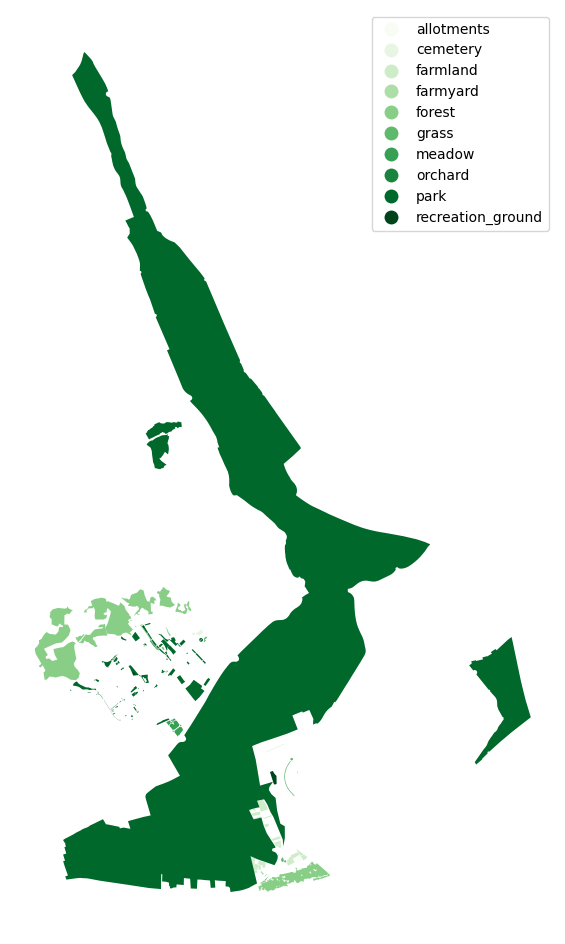

In [6]:
green_categories = ['forest', 'grass', 'meadow', 'orchard', 'vineyard', 'farmland', 'farmyard',
                    'park', 'heath', 'scrub', 'allotments', 'cemetery', 'recreation_ground']
green_land = osm_landuse[osm_landuse['fclass'].isin(green_categories)][['geometry', 'fclass']].copy()
print(f'Green polygons: {len(green_land)}')

ax = green_land.plot(cmap='Greens', column='fclass', linewidth=0.5, legend=True, figsize=(12, 12))
ax.set_axis_off()

## Calculate coverage percentage (vectorized overlay)
Uses `gpd.overlay()` for vectorized intersection — much faster than row-by-row.

In [7]:
def calc_coverage_pct(streets_gdf, landuse_cat_gdf):
    """Return % of 50m buffer covered by landuse_cat_gdf for each street segment."""
    if landuse_cat_gdf.empty:
        return pd.Series(0.0, index=streets_gdf.index)

    buf = gpd.GeoDataFrame(
        {'geometry': streets_gdf.geometry.buffer(50)},
        crs=streets_gdf.crs
    ).reset_index(drop=True)
    buf['area'] = buf.geometry.area
    buf['_i'] = buf.index

    land = landuse_cat_gdf[['geometry']].reset_index(drop=True)

    inter = gpd.overlay(buf[['_i', 'area', 'geometry']], land,
                        how='intersection', keep_geom_type=False)
    inter['ia'] = inter.geometry.area

    ia_sum = inter.groupby('_i')['ia'].sum()
    pct = (ia_sum / buf.set_index('_i')['area'] * 100).reindex(range(len(streets_gdf))).fillna(0)
    return pct.values

## Calculate green percentage in 50 m buffer

In [8]:
print('Calculating green coverage...')
osm_roads['green_pct'] = calc_coverage_pct(osm_roads, green_land[['geometry']])
print(osm_roads['green_pct'].describe())

Calculating green coverage...


count    1613.000000
mean        9.396830
std        19.609796
min         0.000000
25%         0.000000
50%         0.915087
75%        10.937575
max       150.047530
Name: green_pct, dtype: float64


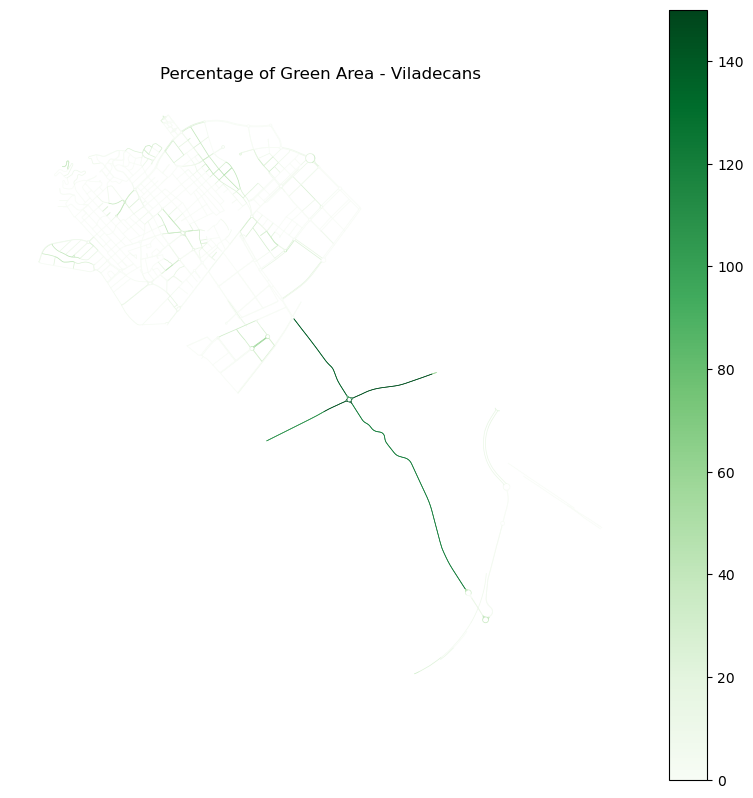

In [9]:
ax = osm_roads.plot(column='green_pct', cmap='Greens', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Percentage of Green Area - Viladecans')
ax.set_axis_off()

In [10]:
commercial_land = osm_landuse[osm_landuse['fclass'].isin(['commercial', 'retail'])][['geometry']].copy()
print(f'Commercial polygons: {len(commercial_land)}')

print('Calculating commercial coverage...')
osm_roads['commercial_pct'] = calc_coverage_pct(osm_roads, commercial_land)
print(osm_roads['commercial_pct'].describe())

Commercial polygons: 6
Calculating commercial coverage...


count    1613.000000
mean        1.495039
std         7.943418
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        89.794943
Name: commercial_pct, dtype: float64


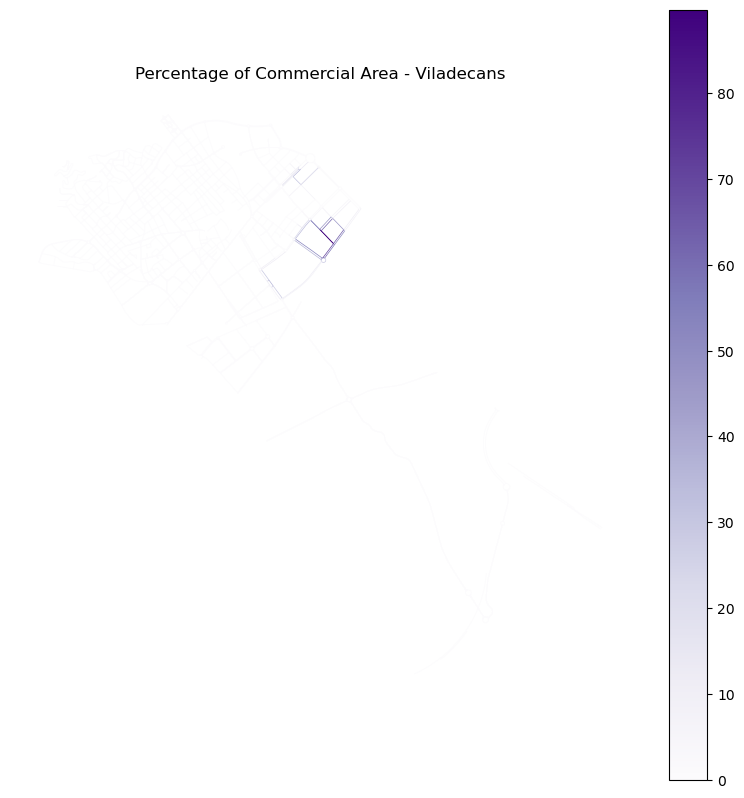

In [11]:
ax = osm_roads.plot(column='commercial_pct', cmap='Purples', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Percentage of Commercial Area - Viladecans')
ax.set_axis_off()

In [12]:
industrial_land = osm_landuse[osm_landuse['fclass'] == 'industrial'][['geometry']].copy()
print(f'Industrial polygons: {len(industrial_land)}')

print('Calculating industrial coverage...')
osm_roads['industrial_pct'] = calc_coverage_pct(osm_roads, industrial_land)
print(osm_roads['industrial_pct'].describe())

Industrial polygons: 19
Calculating industrial coverage...
count    1613.000000
mean        7.837822
std        22.695861
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max       129.701134
Name: industrial_pct, dtype: float64


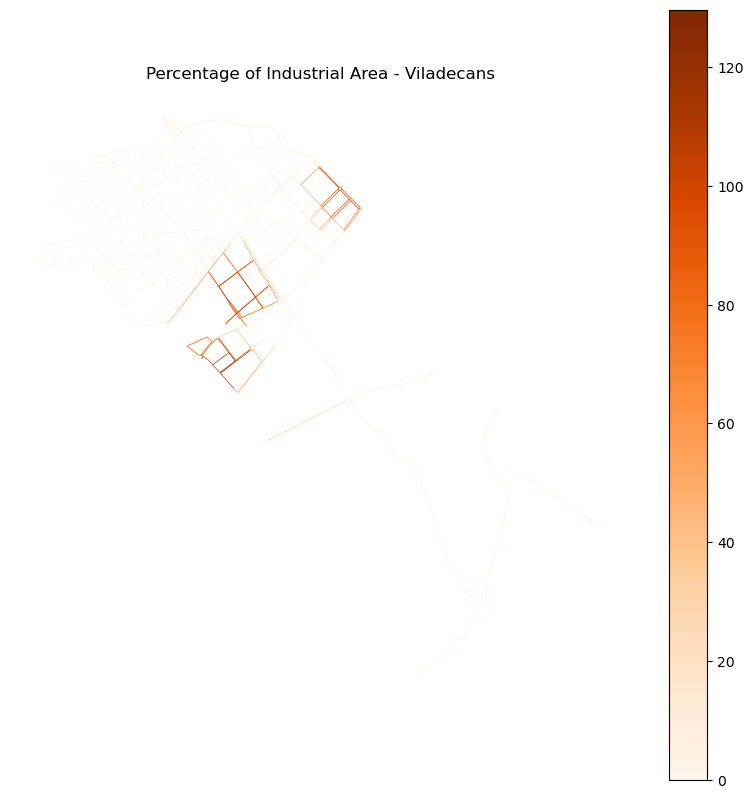

In [13]:
ax = osm_roads.plot(column='industrial_pct', cmap='Oranges', linewidth=0.5, legend=True, figsize=(10, 10))
ax.set_title('Percentage of Industrial Area - Viladecans')
ax.set_axis_off()

## Merge and Export

In [14]:
dataset = pd.DataFrame({
    "road_id": osm_roads["segment_id"],
    "green": osm_roads["green_pct"],
    "industrial": osm_roads["industrial_pct"],
    "commercial": osm_roads["commercial_pct"]
})

dataset = dataset.fillna(0)
display(dataset.head(5))

output_dir = "data"
os.makedirs(output_dir, exist_ok=True)
dataset.to_csv(os.path.join(output_dir, "osm_landuse_features.csv"), index=False)
print("Exported osm_landuse_features.csv")

,road_id,green,industrial,commercial
0,206378333_6315715548_0,0.000000,64.460544,0.0
1,208568922_208568921_0,0.147571,0.000000,0.0
2,208568926_208568922_1,15.415345,0.000000,0.0
3,208595138_208595144_0,9.872402,0.000000,0.0
4,208595144_2332249073_0,6.551946,0.000000,0.0


Exported osm_landuse_features.csv
